Faber-Jackson Relation plot

In [17]:
import sys
!{sys.executable} -m pip install numpy==1.26.4



Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 20.6 MB 2.6 MB/s eta 0:00:01    |██████████████▍                 | 9.2 MB 5.3 MB/s eta 0:00:03     |█████████████████████████▉      | 16.7 MB 2.6 MB/s eta 0:00:02
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [19]:
import sys
!{sys.executable} -m pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 7.9 MB 403 kB/s eta 0:00:01
     |████████████████████████████████| 2.4 MB 4.6 MB/s eta 0:00:01
     |████████████████████████████████| 265 kB 1.7 MB/s eta 0:00:01
     |████████████████████████████████| 65 kB 3.2 MB/s eta 0:00:01
     |████████████████████████████████| 5.3 MB 37.4 MB/s eta 0:00:01
     |████████████████████████████████| 126 kB 5.0 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [20]:
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


Firstly, we define the different columns from the data file. We are given the Mass and velocity dispersion. Mass and luminosity are proportional so for the plot we have to log the Mass to depict a representation of Absolute Magnitude. 

In [21]:
skiprow, catid, type, sigma_re, mstar = np.loadtxt('cleaned_data.txt', unpack=True) # Data saved as array in text file
yvalues = np.log(sigma_re)
xvalues = -2.5 * np.log10(mstar) + 5 * np.log10(70) + 25 # Convert star mass to absolute magnitude. star mass is proportional to luminosity, and absolute magnitude is proportional to luminosity. The constant term is the distance modulus for 70 Mpc.

Now we add a linear fit.

In [22]:
M = xvalues
sigma = yvalues

a,b= np.polyfit(M, sigma, 1) # Fit a linear regression to the data
xcoords = np.linspace(np.min(M), np.max(M), 100) # Create an array of x values for the linear regression line
ycoords = a * xcoords + b # Calculate the y values of the linear regression line

Now we have to plot our data in a graph.

Separate by type.

In [23]:
E = type == 0.0
E_S0 = type == 0.5
S0 = type == 1.0
S0_late = type == 1.5

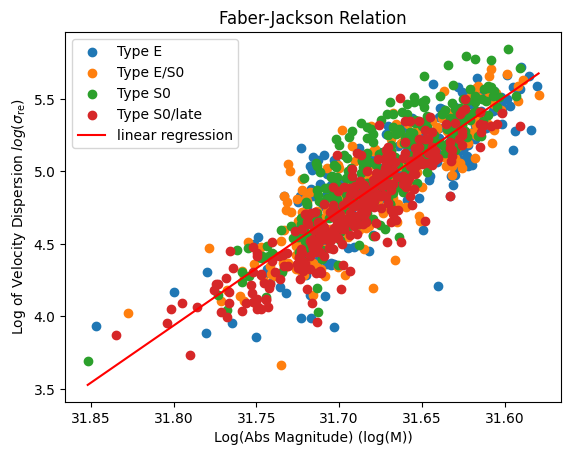

In [27]:
# plt.scatter(xvalues, yvalues, color="black", label="data points") #show data points as black dots

# rewrite for different types

plt.scatter(xvalues[E], yvalues[E], label="Type E")
plt.scatter(xvalues[E_S0], yvalues[E_S0], label="Type E/S0")
plt.scatter(xvalues[S0], yvalues[S0], label="Type S0")
plt.scatter(xvalues[S0_late], yvalues[S0_late], label="Type S0/late")
plt.plot(xcoords, ycoords, color="red", label="linear regression") #show linear regression as red line


plt.gca().invert_xaxis() #invert x axis to match the convention of absolute magnitude (brighter objects have lower magnitudes)

plt.legend(loc="best")
plt.title("Faber-Jackson Relation")
plt.xlabel("Log(Abs Magnitude) (log(M))")
plt.ylabel("Log of Velocity Dispersion $log(\\sigma_{\\text{re}})$")
plt.show()

In [34]:
from scipy.optimize import curve_fit

def relation(Mag, k):
    return k * Mag

params, covariance = curve_fit(relation, M, sigma)

k = params 

fit = relation(M,k)

SS_res = np.sum((sigma - fit)**2)
SS_tot = np.sum(sigma - np.mean(sigma)**2)

R2 = 1- SS_res/SS_tot

corr_coef = np.sqrt(R2)

print("k =", k)
print("R^2 =", R2)
print("r=", corr_coef)

k = [0.15474107]
R^2 = 1.008406011298834
r= 1.004194209950861


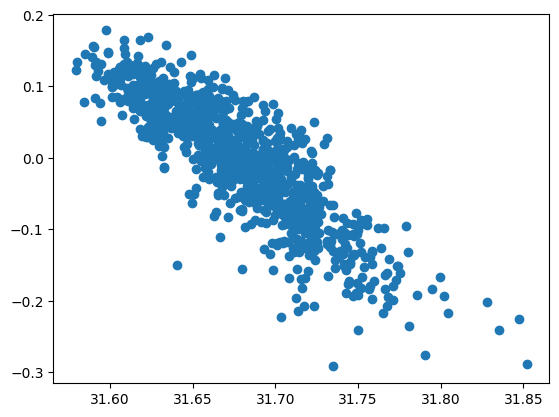

In [39]:
# finding the residuals at each point -> I think we can put this under the curve to show how each point varies

res = sigma - fit

res1 = np.log(sigma) - np.log(fit)
plt.scatter(M, res1)